In [20]:
!pip install requests

In [40]:
import requests
import pandas as pd

# ============================================================
# STEP 1: Get correct API URL
# ============================================================
def get_cms_api_url(title):
    catalog_url = "https://data.cms.gov/data.json"
    print("🔍 Searching CMS catalog...")
    response = requests.get(catalog_url)
    catalog = response.json()
    
    for dataset in catalog['dataset']:
        if title == dataset['title']:
            for distro in dataset['distribution']:
                if 'format' in distro and 'description' in distro:
                    if distro['format'] == "API" and distro['description'] == "latest":
                        print(f"✅ Found: {distro['accessURL']}")
                        return distro['accessURL']
    return None

# ============================================================
# STEP 2: Fetch data with correct title
# ============================================================
def fetch_prescriber_data(state="CA", size=5000):
    
    # ✅ EXACT title from your list
    title = "Medicare Part D Prescribers - by Provider and Drug"
    api_url = get_cms_api_url(title)
    
    if not api_url:
        print("❌ URL not found")
        return None
    
    params = {
        "size": size,
        "offset": 0,
        "filter[Prscrbr_State_Abrvtn]": state
    }
    
    print(f"📥 Fetching {size} records for state: {state}...")
    response = requests.get(api_url, params=params)
    
    if response.status_code == 200:
        df = pd.DataFrame(response.json())
        print(f"✅ Success! {len(df)} rows, {len(df.columns)} columns")
        return df
    else:
        print(f"❌ Error {response.status_code}: {response.text[:300]}")
        return None

# ============================================================
# STEP 3: Run & Preview
# ============================================================
df = fetch_prescriber_data(state="CA", size=5000)

if df is not None:
    print("\n📋 Column Names:")
    print(df.columns.tolist())
    
    print("\n👀 First 5 rows:")
    print(df.head())
    
    print("\n📊 Data Types:")
    print(df.dtypes)

🔍 Searching CMS catalog...
✅ Found: https://data.cms.gov/data-api/v1/dataset/9552739e-3d05-4c1b-8eff-ecabf391e2e5/data
📥 Fetching 5000 records for state: CA...
✅ Success! 5000 rows, 22 columns

📋 Column Names:
['Prscrbr_NPI', 'Prscrbr_Last_Org_Name', 'Prscrbr_First_Name', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_State_FIPS', 'Prscrbr_Type', 'Prscrbr_Type_Src', 'Brnd_Name', 'Gnrc_Name', 'Tot_Clms', 'Tot_30day_Fills', 'Tot_Day_Suply', 'Tot_Drug_Cst', 'Tot_Benes', 'GE65_Sprsn_Flag', 'GE65_Tot_Clms', 'GE65_Tot_30day_Fills', 'GE65_Tot_Drug_Cst', 'GE65_Tot_Day_Suply', 'GE65_Bene_Sprsn_Flag', 'GE65_Tot_Benes']

👀 First 5 rows:
  Prscrbr_NPI Prscrbr_Last_Org_Name Prscrbr_First_Name Prscrbr_City  \
0  1003001363               Stevens            Charles    El Centro   
1  1003001363               Stevens            Charles    El Centro   
2  1003001363               Stevens            Charles    El Centro   
3  1003001363               Stevens            Charles    El Centro   
4  100300

In [41]:
df.to_csv("ca_prescribers.csv", index=False)

In [42]:
df.columns

Index(['Prscrbr_NPI', 'Prscrbr_Last_Org_Name', 'Prscrbr_First_Name',
       'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_State_FIPS',
       'Prscrbr_Type', 'Prscrbr_Type_Src', 'Brnd_Name', 'Gnrc_Name',
       'Tot_Clms', 'Tot_30day_Fills', 'Tot_Day_Suply', 'Tot_Drug_Cst',
       'Tot_Benes', 'GE65_Sprsn_Flag', 'GE65_Tot_Clms', 'GE65_Tot_30day_Fills',
       'GE65_Tot_Drug_Cst', 'GE65_Tot_Day_Suply', 'GE65_Bene_Sprsn_Flag',
       'GE65_Tot_Benes'],
      dtype='object')

235 doctors
    ↓
Who drives the most prescriptions?
Which specialty is the biggest source?
Which doctor-drug combo is most valuable?

In [43]:
df.head(20)

,Prscrbr_NPI,Prscrbr_Last_Org_Name,Prscrbr_First_Name,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_State_FIPS,Prscrbr_Type,Prscrbr_Type_Src,Brnd_Name,Gnrc_Name,...,Tot_Day_Suply,Tot_Drug_Cst,Tot_Benes,GE65_Sprsn_Flag,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Drug_Cst,GE65_Tot_Day_Suply,GE65_Bene_Sprsn_Flag,GE65_Tot_Benes
0,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Claim-Specialty,Acetaminophen-Codeine,Acetaminophen With Codeine,...,661,610.44,16,,21,21,275.47,414,#,
1,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Claim-Specialty,Amitriptyline Hcl,Amitriptyline Hcl,...,3082,1564.91,40,,32,38,431.97,1140,,19
2,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Claim-Specialty,Baclofen,Baclofen,...,4140,3390.42,58,,87,89,2172.46,2670,,38
3,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Claim-Specialty,Buprenorphine,Buprenorphine,...,650,9206.49,13,#,,,,,*,
4,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Claim-Specialty,Buprenorphine-Naloxone,Buprenorphine Hcl/Naloxone Hcl,...,390,3256.54,,*,,,,,*,
5,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Claim-Specialty,Butalbital-Acetaminophen-Caffe,Butalb/Acetaminophen/Caffeine,...,510,487.63,,*,,,,,*,
6,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Claim-Specialty,Celecoxib,Celecoxib,...,1260,1523.04,15,,23,27,666.63,810,#,
7,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Claim-Specialty,Cephalexin,Cephalexin,...,203,210.74,21,#,,,,,#,
8,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Claim-Specialty,Cyclobenzaprine Hcl,Cyclobenzaprine Hcl,...,4545,1641.11,61,,94,94,738.91,2820,,36
9,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Claim-Specialty,Diclofenac Sodium,Diclofenac Sodium,...,6801,6502.47,102,,145,164.4,4057.25,4187,,67


In [44]:
numeric_cols = ['Tot_Clms', 'Tot_30day_Fills', 'Tot_Day_Suply', 'Tot_Drug_Cst', 'Tot_Benes',
    'GE65_Tot_Clms', 'GE65_Tot_30day_Fills', 'GE65_Tot_Drug_Cst',
    'GE65_Tot_Day_Suply', 'GE65_Tot_Benes']

In [45]:
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [27]:
df.isnull().sum()

Prscrbr_NPI                 0
Prscrbr_Last_Org_Name       0
Prscrbr_First_Name          0
Prscrbr_City                0
Prscrbr_State_Abrvtn        0
Prscrbr_State_FIPS          0
Prscrbr_Type                0
Prscrbr_Type_Src            0
Brnd_Name                   0
Gnrc_Name                   0
Tot_Clms                    0
Tot_30day_Fills             0
Tot_Day_Suply               0
Tot_Drug_Cst                0
Tot_Benes                2886
GE65_Sprsn_Flag             0
GE65_Tot_Clms            2124
GE65_Tot_30day_Fills     2124
GE65_Tot_Drug_Cst        2124
GE65_Tot_Day_Suply       2124
GE65_Bene_Sprsn_Flag        0
GE65_Tot_Benes           4386
dtype: int64

In [46]:
import numpy as np
df['GE65_Sprsn_Flag'] = df['GE65_Sprsn_Flag'].replace('*', np.nan)
df['GE65_Sprsn_Flag'] = df['GE65_Sprsn_Flag'].replace('#', np.nan)
df['GE65_Bene_Sprsn_Flag'] = df['GE65_Bene_Sprsn_Flag'].replace('*', np.nan)
df['GE65_Bene_Sprsn_Flag'] = df['GE65_Bene_Sprsn_Flag'].replace('#', np.nan)




In [47]:
df[df['Prscrbr_City']== 'El Centro']

,Prscrbr_NPI,Prscrbr_Last_Org_Name,Prscrbr_First_Name,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_State_FIPS,Prscrbr_Type,Prscrbr_Type_Src,Brnd_Name,Gnrc_Name,...,Tot_Day_Suply,Tot_Drug_Cst,Tot_Benes,GE65_Sprsn_Flag,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Drug_Cst,GE65_Tot_Day_Suply,GE65_Bene_Sprsn_Flag,GE65_Tot_Benes
0,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Claim-Specialty,Acetaminophen-Codeine,Acetaminophen With Codeine,...,661,610.44,16.0,,21.0,21.0,275.47,414.0,NaN,NaN
1,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Claim-Specialty,Amitriptyline Hcl,Amitriptyline Hcl,...,3082,1564.91,40.0,,32.0,38.0,431.97,1140.0,,19.0
2,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Claim-Specialty,Baclofen,Baclofen,...,4140,3390.42,58.0,,87.0,89.0,2172.46,2670.0,,38.0
3,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Claim-Specialty,Buprenorphine,Buprenorphine,...,650,9206.49,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Claim-Specialty,Buprenorphine-Naloxone,Buprenorphine Hcl/Naloxone Hcl,...,390,3256.54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Claim-Specialty,Butalbital-Acetaminophen-Caffe,Butalb/Acetaminophen/Caffeine,...,510,487.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Claim-Specialty,Celecoxib,Celecoxib,...,1260,1523.04,15.0,,23.0,27.0,666.63,810.0,NaN,NaN
7,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Claim-Specialty,Cephalexin,Cephalexin,...,203,210.74,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Claim-Specialty,Cyclobenzaprine Hcl,Cyclobenzaprine Hcl,...,4545,1641.11,61.0,,94.0,94.0,738.91,2820.0,,36.0
9,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Claim-Specialty,Diclofenac Sodium,Diclofenac Sodium,...,6801,6502.47,102.0,,145.0,164.4,4057.25,4187.0,,67.0


In [48]:
df = df[df['Tot_Clms'] > 0]

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Prscrbr_NPI            5000 non-null   object 
 1   Prscrbr_Last_Org_Name  5000 non-null   object 
 2   Prscrbr_First_Name     5000 non-null   object 
 3   Prscrbr_City           5000 non-null   object 
 4   Prscrbr_State_Abrvtn   5000 non-null   object 
 5   Prscrbr_State_FIPS     5000 non-null   object 
 6   Prscrbr_Type           5000 non-null   object 
 7   Prscrbr_Type_Src       5000 non-null   object 
 8   Brnd_Name              5000 non-null   object 
 9   Gnrc_Name              5000 non-null   object 
 10  Tot_Clms               5000 non-null   int64  
 11  Tot_30day_Fills        5000 non-null   float64
 12  Tot_Day_Suply          5000 non-null   int64  
 13  Tot_Drug_Cst           5000 non-null   float64
 14  Tot_Benes              2114 non-null   float64
 15  GE65

In [52]:
# Null count of Tot_Benes per Specialty
print("=== Nulls by Specialty ===")
null_by_specialty = df.groupby('Prscrbr_Type')['Tot_Benes'].apply(
    lambda x: x.isnull().sum()
).sort_values(ascending=False)
print(null_by_specialty[null_by_specialty > 0])

print("\n=== Total vs Null per Specialty ===")
summary = df.groupby('Prscrbr_Type')['Tot_Benes'].agg(
    Total='count',
    Nulls=lambda x: x.isnull().sum()
)
summary['Null_%'] = (summary['Nulls'] / (summary['Total'] + summary['Nulls']) * 100).round(1)
summary = summary[summary['Nulls'] > 0].sort_values('Null_%', ascending=False)
print(summary)

=== Nulls by Specialty ===
Prscrbr_Type
Internal Medicine                       888
Family Practice                         536
Nurse Practitioner                      298
Physician Assistant                     154
Psychiatry                              150
Neurology                               144
Infectious Disease                      105
Pulmonary Disease                        84
Endocrinology                            65
Cardiology                               56
General Surgery                          53
Nephrology                               47
Dermatology                              39
General Practice                         38
Psychiatry & Neurology                   36
Obstetrics & Gynecology                  27
Geriatric Medicine                       24
Urology                                  22
Ophthalmology                            22
Optometry                                15
Otolaryngology                           14
Gastroenterology                    

In [53]:
# Drop fully-null specialties
fully_null = ['Certified Nurse Midwife', 'Critical Care (Intensivists)',
              'Preventive Medicine', 'Physical Medicine and Rehabilitation']

df = df[~df['Prscrbr_Type'].isin(fully_null)]

In [54]:
# Level 1: Specialty + Drug
df['Tot_Benes'] = df.groupby(['Prscrbr_Type', 'Gnrc_Name'])['Tot_Benes']\
                    .transform(lambda x: x.fillna(x.median()))

# Level 2: Specialty only (fallback)
df['Tot_Benes'] = df.groupby('Prscrbr_Type')['Tot_Benes']\
                    .transform(lambda x: x.fillna(x.median()))

C:\Users\anfas\AppData\Local\Temp\ipykernel_34800\676942026.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Tot_Benes'] = df.groupby(['Prscrbr_Type', 'Gnrc_Name'])['Tot_Benes']\
C:\Users\anfas\AppData\Local\Temp\ipykernel_34800\676942026.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Tot_Benes'] = df.groupby('Prscrbr_Type')['Tot_Benes']\


In [55]:
df.isnull().sum()

Prscrbr_NPI                 0
Prscrbr_Last_Org_Name       0
Prscrbr_First_Name          0
Prscrbr_City                0
Prscrbr_State_Abrvtn        0
Prscrbr_State_FIPS          0
Prscrbr_Type                0
Prscrbr_Type_Src            0
Brnd_Name                   0
Gnrc_Name                   0
Tot_Clms                    0
Tot_30day_Fills             0
Tot_Day_Suply               0
Tot_Drug_Cst                0
Tot_Benes                   0
GE65_Sprsn_Flag          2121
GE65_Tot_Clms            2121
GE65_Tot_30day_Fills     2121
GE65_Tot_Drug_Cst        2121
GE65_Tot_Day_Suply       2121
GE65_Bene_Sprsn_Flag     4379
GE65_Tot_Benes           4379
dtype: int64

In [58]:
# ── Zero out where flag is NaN (suppressed) ──────────────
senior_clm_cols = [
    'GE65_Tot_Clms', 'GE65_Tot_30day_Fills',
    'GE65_Tot_Drug_Cst', 'GE65_Tot_Day_Suply'
]

df.loc[df['GE65_Sprsn_Flag'].isna(), senior_clm_cols] = 0
df.loc[df['GE65_Bene_Sprsn_Flag'].isna(), 'GE65_Tot_Benes'] = 0

# ── Fill any remaining nulls with 0 ──────────────────────
all_senior_cols = senior_clm_cols + ['GE65_Tot_Benes']
df[all_senior_cols] = df[all_senior_cols].fillna(0)

# ── Drop flag columns ─────────────────────────────────────
df = df.drop(columns=['GE65_Sprsn_Flag', 'GE65_Bene_Sprsn_Flag', 'Prscrbr_Type_Src'])

# ── Verify ────────────────────────────────────────────────
print("Shape:", df.shape)
print("\nNon-zero counts:")
for col in all_senior_cols:
    print(f"  {col}: {(df[col] > 0).sum()}")

print("\nNull counts:")
print(df.isnull().sum())

Shape: (4993, 19)

Non-zero counts:
  GE65_Tot_Clms: 2747
  GE65_Tot_30day_Fills: 2747
  GE65_Tot_Drug_Cst: 2747
  GE65_Tot_Day_Suply: 2747
  GE65_Tot_Benes: 613

Null counts:
Prscrbr_NPI              0
Prscrbr_Last_Org_Name    0
Prscrbr_First_Name       0
Prscrbr_City             0
Prscrbr_State_Abrvtn     0
Prscrbr_State_FIPS       0
Prscrbr_Type             0
Brnd_Name                0
Gnrc_Name                0
Tot_Clms                 0
Tot_30day_Fills          0
Tot_Day_Suply            0
Tot_Drug_Cst             0
Tot_Benes                0
GE65_Tot_Clms            0
GE65_Tot_30day_Fills     0
GE65_Tot_Drug_Cst        0
GE65_Tot_Day_Suply       0
GE65_Tot_Benes           0
dtype: int64


C:\Users\anfas\AppData\Local\Temp\ipykernel_34800\4233770101.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[all_senior_cols] = df[all_senior_cols].fillna(0)


In [59]:
df.head(10)

,Prscrbr_NPI,Prscrbr_Last_Org_Name,Prscrbr_First_Name,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_State_FIPS,Prscrbr_Type,Brnd_Name,Gnrc_Name,Tot_Clms,Tot_30day_Fills,Tot_Day_Suply,Tot_Drug_Cst,Tot_Benes,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Drug_Cst,GE65_Tot_Day_Suply,GE65_Tot_Benes
0,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Acetaminophen-Codeine,Acetaminophen With Codeine,32,32.0,661,610.44,16.0,21.0,21.0,275.47,414.0,0.0
1,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Amitriptyline Hcl,Amitriptyline Hcl,87,103.0,3082,1564.91,40.0,32.0,38.0,431.97,1140.0,19.0
2,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Baclofen,Baclofen,132,138.0,4140,3390.42,58.0,87.0,89.0,2172.46,2670.0,38.0
3,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Buprenorphine,Buprenorphine,23,23.0,650,9206.49,13.0,0.0,0.0,0.00,0.0,0.0
4,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Buprenorphine-Naloxone,Buprenorphine Hcl/Naloxone Hcl,13,13.0,390,3256.54,32.0,0.0,0.0,0.00,0.0,0.0
5,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Butalbital-Acetaminophen-Caffe,Butalb/Acetaminophen/Caffeine,17,17.0,510,487.63,32.0,0.0,0.0,0.00,0.0,0.0
6,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Celecoxib,Celecoxib,38,42.0,1260,1523.04,15.0,23.0,27.0,666.63,810.0,0.0
7,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Cephalexin,Cephalexin,23,23.0,203,210.74,21.0,0.0,0.0,0.00,0.0,0.0
8,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Cyclobenzaprine Hcl,Cyclobenzaprine Hcl,151,153.0,4545,1641.11,61.0,94.0,94.0,738.91,2820.0,36.0
9,1003001363,Stevens,Charles,El Centro,CA,06,Pain Management,Diclofenac Sodium,Diclofenac Sodium,226,265.6,6801,6502.47,102.0,145.0,164.4,4057.25,4187.0,67.0


In [60]:

# ── 1. Refill Rate ───────────────────────────────────
# How many prescriptions per unique patient?
df['Refill_Rate'] = df['Tot_Clms'] / df['Tot_Benes']

# ── 2. Cost Per Claim ────────────────────────────────
# Average cost per prescription
df['Cost_Per_Claim'] = df['Tot_Drug_Cst'] / df['Tot_Clms']

# ── 3. Days Per Claim ────────────────────────────────
# Average days of medication per prescription
df['Days_Per_Claim'] = df['Tot_Day_Suply'] / df['Tot_Clms']

# ── 4. Senior Ratio ──────────────────────────────────
# What % of prescriptions go to 65+ patients?
df['Senior_Ratio'] = df['GE65_Tot_Clms'] / df['Tot_Clms']

# ── 5. Senior Cost Ratio ─────────────────────────────
# What % of drug cost comes from senior patients?
df['Senior_Cost_Ratio'] = df['GE65_Tot_Drug_Cst'] / df['Tot_Drug_Cst']

# ── 6. Fix division errors ───────────────────────────
new_features = ['Refill_Rate', 'Cost_Per_Claim', 'Days_Per_Claim',
                'Senior_Ratio', 'Senior_Cost_Ratio']

df[new_features] = df[new_features].replace([np.inf, -np.inf], np.nan).fillna(0)


In [61]:
df[new_features].describe()

,Refill_Rate,Cost_Per_Claim,Days_Per_Claim,Senior_Ratio,Senior_Cost_Ratio
count,4993.000000,4993.000000,4993.000000,4993.000000,4993.000000
mean,1.842835,238.802898,46.091198,0.502423,0.500755
std,1.361134,1179.280314,26.577147,0.471938,0.473431
min,0.141026,0.730769,1.000000,0.000000,0.000000
25%,0.888889,11.649783,27.818182,0.000000,0.000000
50%,1.352941,20.459130,38.500000,0.612903,0.602791
75%,2.500000,50.570588,69.600000,1.000000,1.000000
max,12.857143,25410.359024,132.177419,1.000000,1.000000


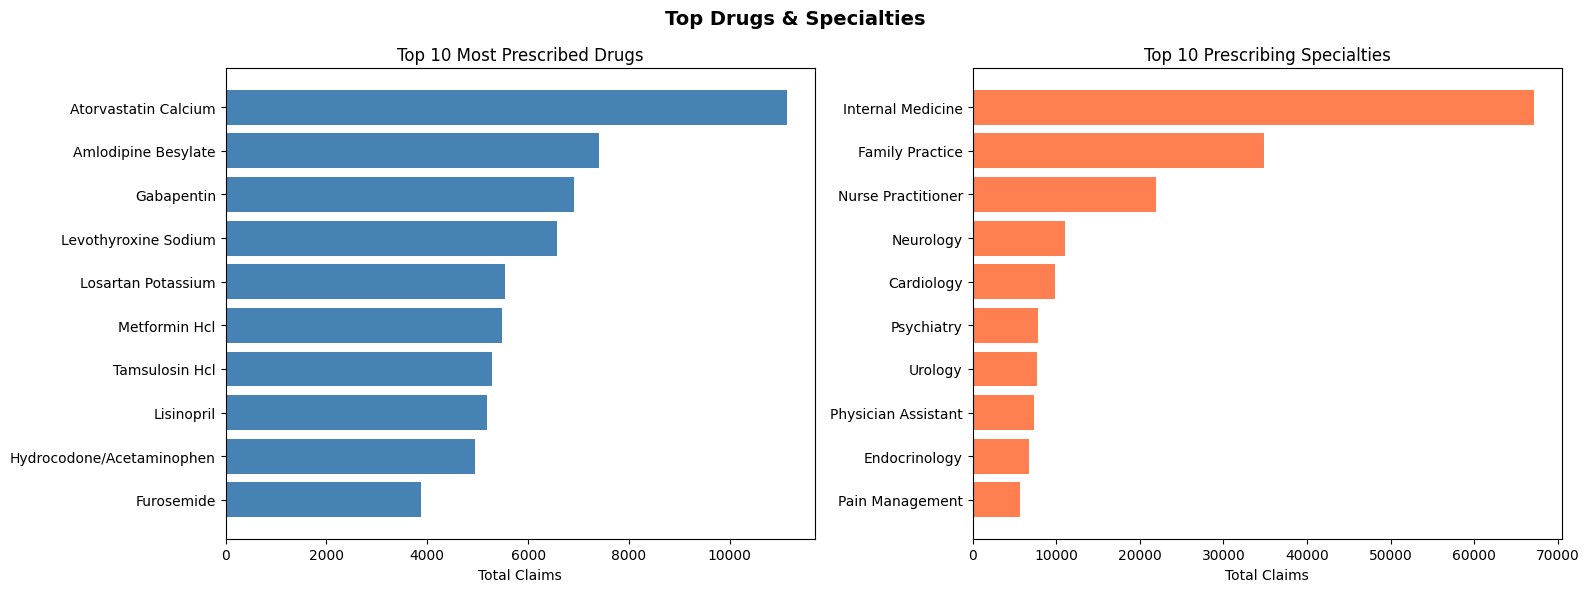

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top Drugs & Specialties', fontsize=14, fontweight='bold')

# ── Top 10 Drugs by Total Claims ──────────────────────
top_drugs = df.groupby('Gnrc_Name')['Tot_Clms']\
              .sum().sort_values(ascending=True).tail(10)

axes[0].barh(top_drugs.index, top_drugs.values, color='steelblue')
axes[0].set_title('Top 10 Most Prescribed Drugs')
axes[0].set_xlabel('Total Claims')

# ── Top 10 Specialties by Total Claims ────────────────
top_spec = df.groupby('Prscrbr_Type')['Tot_Clms']\
             .sum().sort_values(ascending=True).tail(10)

axes[1].barh(top_spec.index, top_spec.values, color='coral')
axes[1].set_title('Top 10 Prescribing Specialties')
axes[1].set_xlabel('Total Claims')

plt.tight_layout()
plt.show()

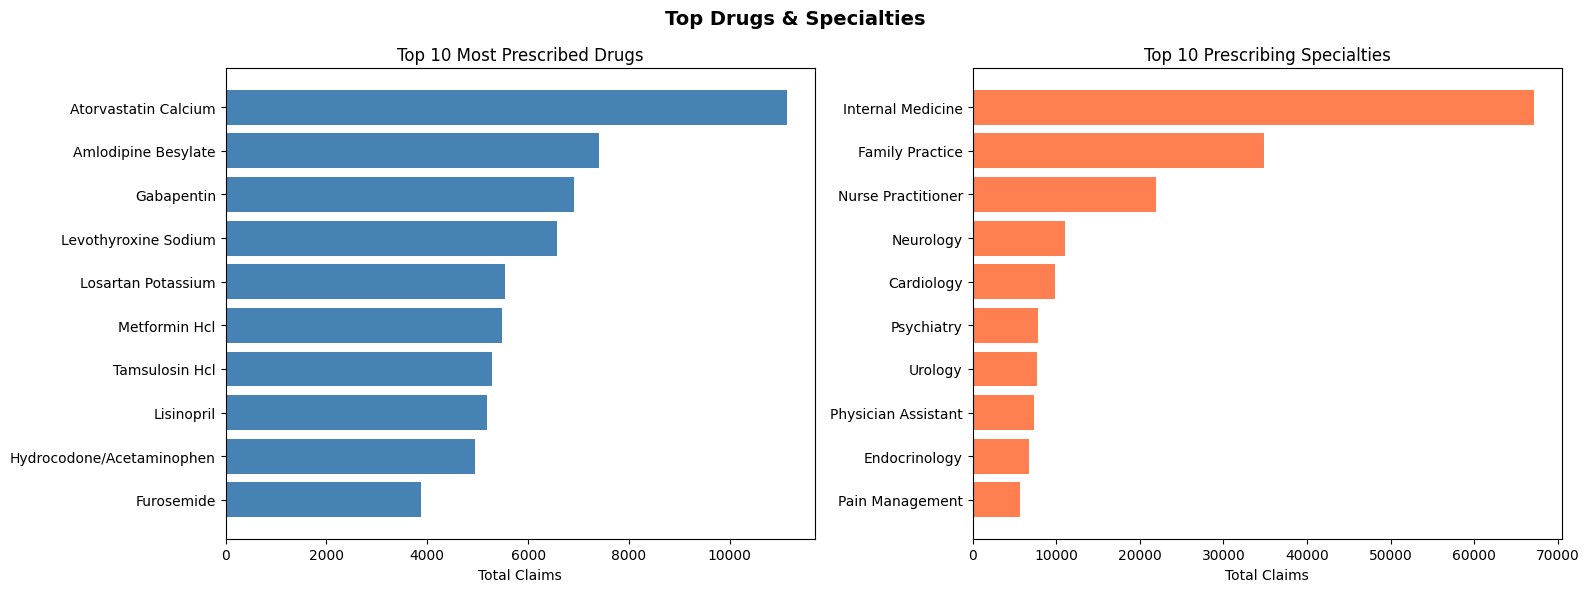

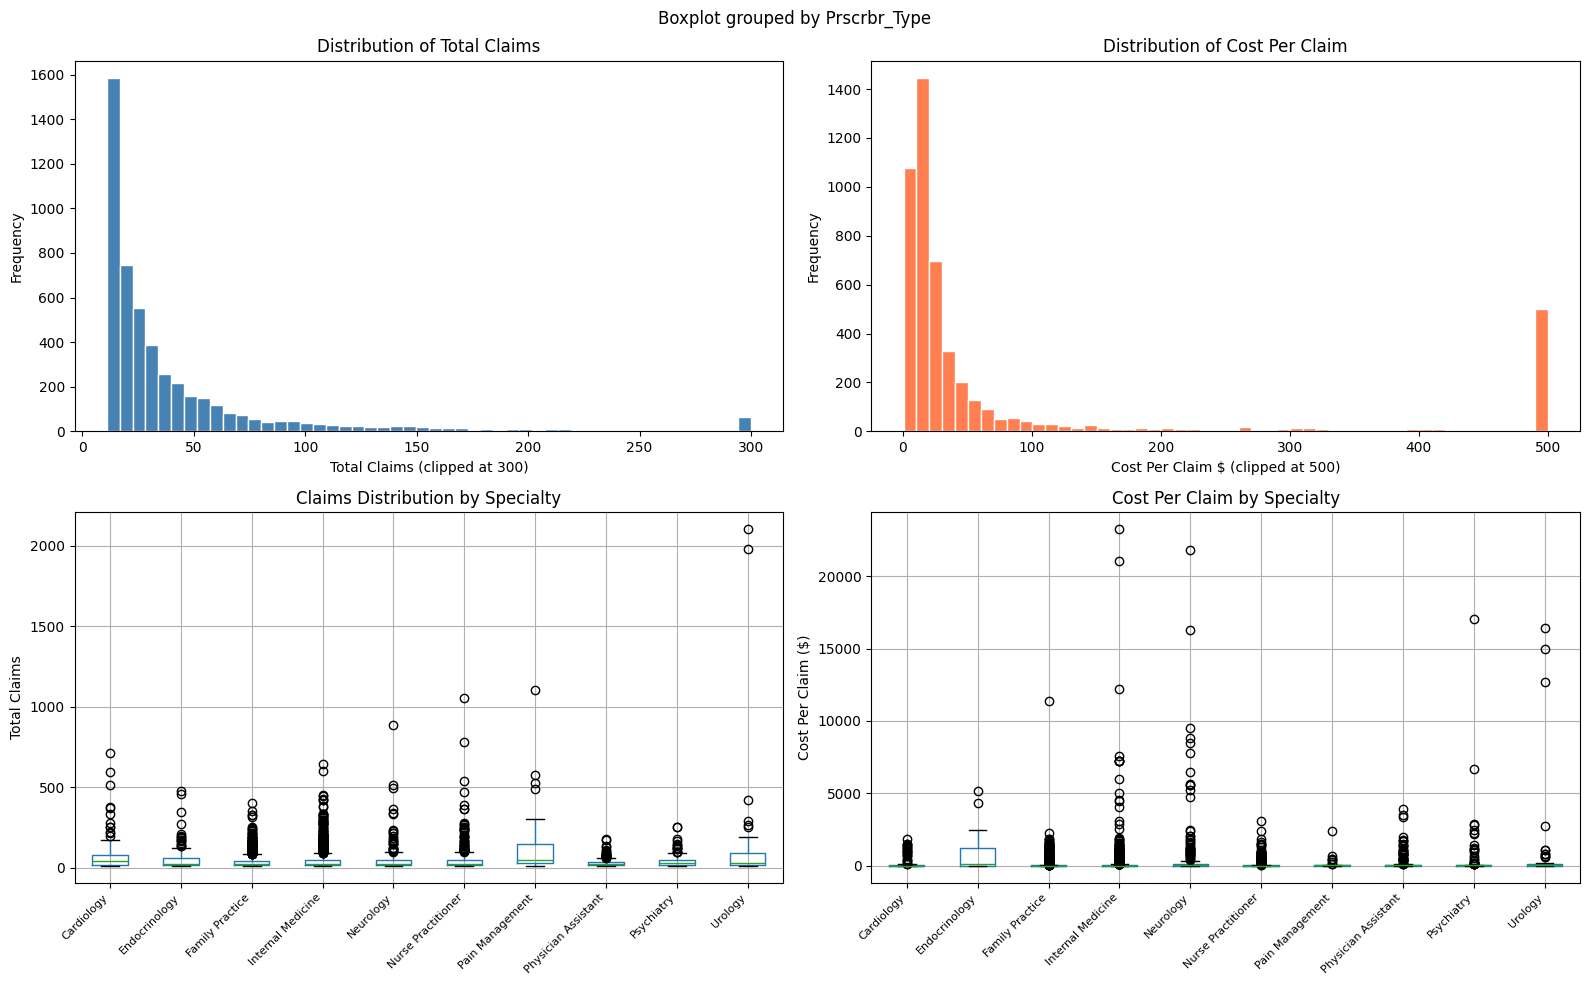

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Distribution of Claims & Costs', fontsize=14, fontweight='bold')

# ── 1. Distribution of Total Claims ───────────────────
axes[0,0].hist(df['Tot_Clms'].clip(0, 300), bins=50, 
               color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribution of Total Claims')
axes[0,0].set_xlabel('Total Claims (clipped at 300)')
axes[0,0].set_ylabel('Frequency')

# ── 2. Distribution of Cost Per Claim ─────────────────
axes[0,1].hist(df['Cost_Per_Claim'].clip(0, 500), bins=50,
               color='coral', edgecolor='white')
axes[0,1].set_title('Distribution of Cost Per Claim')
axes[0,1].set_xlabel('Cost Per Claim $ (clipped at 500)')
axes[0,1].set_ylabel('Frequency')

# ── 3. Total Claims by Specialty (boxplot) ────────────
top10_spec = df.groupby('Prscrbr_Type')['Tot_Clms']\
               .sum().sort_values(ascending=False)\
               .head(10).index

df_top = df[df['Prscrbr_Type'].isin(top10_spec)]
df_top.boxplot(column='Tot_Clms', by='Prscrbr_Type',
               ax=axes[1,0], rot=45)
axes[1,0].set_title('Claims Distribution by Specialty')
axes[1,0].set_xlabel('')
axes[1,0].set_ylabel('Total Claims')
plt.sca(axes[1,0])
plt.xticks(ha='right', fontsize=8)

# ── 4. Cost Per Claim by Specialty ────────────────────
df_top.boxplot(column='Cost_Per_Claim', by='Prscrbr_Type',
               ax=axes[1,1], rot=45)
axes[1,1].set_title('Cost Per Claim by Specialty')
axes[1,1].set_xlabel('')
axes[1,1].set_ylabel('Cost Per Claim ($)')
plt.sca(axes[1,1])
plt.xticks(ha='right', fontsize=8)

plt.tight_layout()
plt.show()

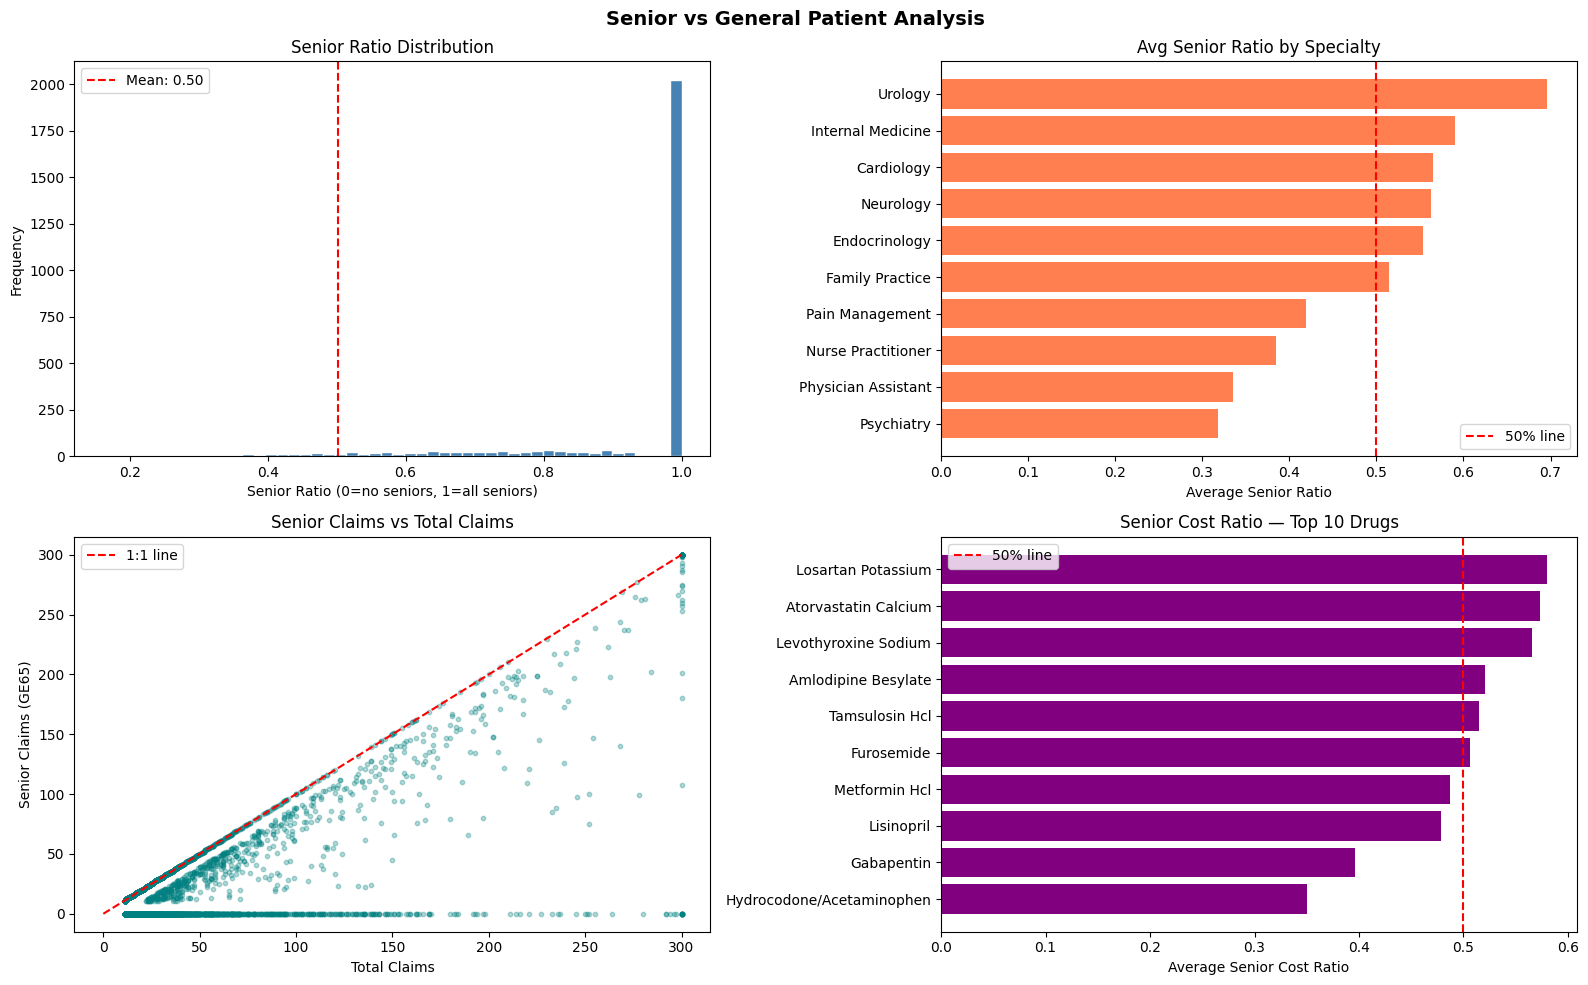

In [65]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Senior vs General Patient Analysis', fontsize=14, fontweight='bold')

# ── 1. Senior Ratio Distribution ──────────────────────
axes[0,0].hist(df[df['Senior_Ratio'] > 0]['Senior_Ratio'], 
               bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Senior Ratio Distribution')
axes[0,0].set_xlabel('Senior Ratio (0=no seniors, 1=all seniors)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(df['Senior_Ratio'].mean(), color='red', 
                   linestyle='--', label=f"Mean: {df['Senior_Ratio'].mean():.2f}")
axes[0,0].legend()

# ── 2. Senior Ratio by Specialty ──────────────────────
top10_spec = df.groupby('Prscrbr_Type')['Tot_Clms']\
               .sum().sort_values(ascending=False).head(10).index

senior_by_spec = df[df['Prscrbr_Type'].isin(top10_spec)]\
                   .groupby('Prscrbr_Type')['Senior_Ratio']\
                   .mean().sort_values(ascending=True)

axes[0,1].barh(senior_by_spec.index, senior_by_spec.values, color='coral')
axes[0,1].set_title('Avg Senior Ratio by Specialty')
axes[0,1].set_xlabel('Average Senior Ratio')
axes[0,1].axvline(0.5, color='red', linestyle='--', label='50% line')
axes[0,1].legend()

# ── 3. Senior vs Total Claims scatter ─────────────────
axes[1,0].scatter(df['Tot_Clms'].clip(0, 300), 
                  df['GE65_Tot_Clms'].clip(0, 300),
                  alpha=0.3, color='teal', s=10)
axes[1,0].plot([0, 300], [0, 300], 'r--', label='1:1 line')
axes[1,0].set_title('Senior Claims vs Total Claims')
axes[1,0].set_xlabel('Total Claims')
axes[1,0].set_ylabel('Senior Claims (GE65)')
axes[1,0].legend()

# ── 4. Senior Cost Ratio by Top Drugs ─────────────────
top10_drugs = df.groupby('Gnrc_Name')['Tot_Clms']\
                .sum().sort_values(ascending=False).head(10).index

senior_cost_drug = df[df['Gnrc_Name'].isin(top10_drugs)]\
                     .groupby('Gnrc_Name')['Senior_Cost_Ratio']\
                     .mean().sort_values(ascending=True)

axes[1,1].barh(senior_cost_drug.index, senior_cost_drug.values, color='purple')
axes[1,1].set_title('Senior Cost Ratio — Top 10 Drugs')
axes[1,1].set_xlabel('Average Senior Cost Ratio')
axes[1,1].axvline(0.5, color='red', linestyle='--', label='50% line')
axes[1,1].legend()

plt.tight_layout()
plt.show()

Total doctors: 231


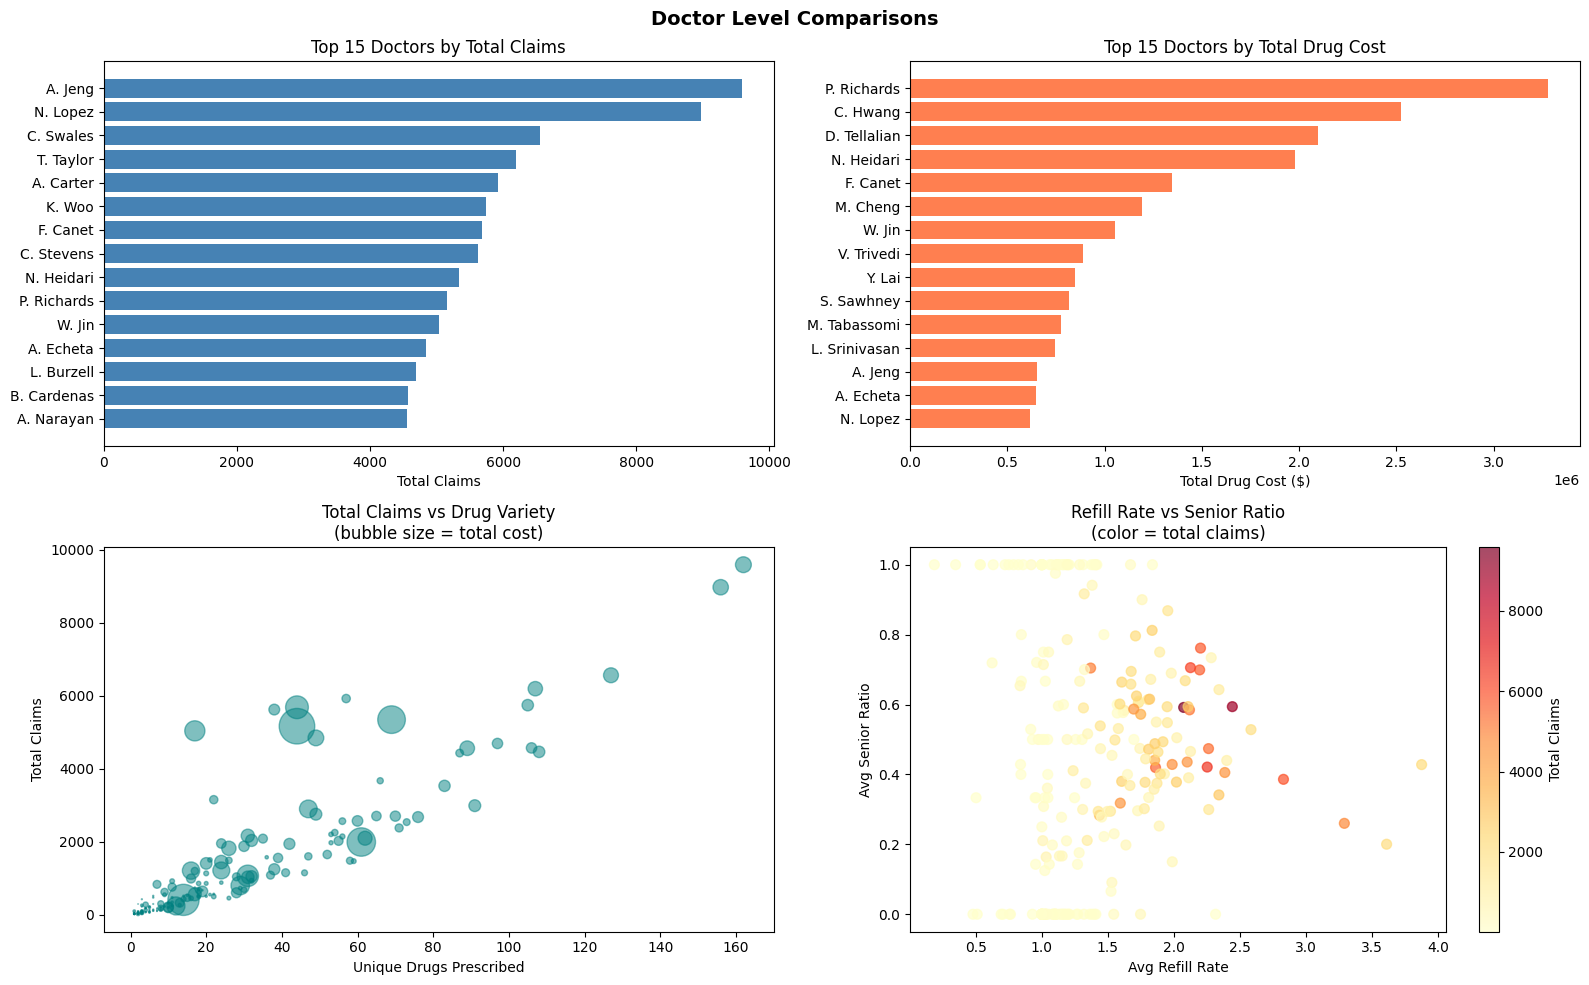

In [66]:
# ── Aggregate to Doctor Level first ───────────────────
doctor_df = df.groupby(['Prscrbr_NPI', 'Prscrbr_Last_Org_Name',
                        'Prscrbr_First_Name', 'Prscrbr_Type',
                        'Prscrbr_City']).agg(
    Total_Claims       = ('Tot_Clms',         'sum'),
    Total_Cost         = ('Tot_Drug_Cst',      'sum'),
    Total_Patients     = ('Tot_Benes',         'sum'),
    Unique_Drugs       = ('Gnrc_Name',         'nunique'),
    Avg_Refill_Rate    = ('Refill_Rate',       'mean'),
    Avg_Cost_Per_Claim = ('Cost_Per_Claim',    'mean'),
    Avg_Senior_Ratio   = ('Senior_Ratio',      'mean'),
).reset_index()

print(f"Total doctors: {len(doctor_df)}")

# ── Now plot ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Doctor Level Comparisons', fontsize=14, fontweight='bold')

# ── 1. Top 15 Doctors by Total Claims ─────────────────
top15 = doctor_df.nlargest(15, 'Total_Claims')
top15['Name'] = top15['Prscrbr_First_Name'].str[:1] + '. ' + \
                top15['Prscrbr_Last_Org_Name']

axes[0,0].barh(top15['Name'], top15['Total_Claims'], color='steelblue')
axes[0,0].set_title('Top 15 Doctors by Total Claims')
axes[0,0].set_xlabel('Total Claims')
axes[0,0].invert_yaxis()

# ── 2. Top 15 Doctors by Total Cost ───────────────────
top15_cost = doctor_df.nlargest(15, 'Total_Cost')
top15_cost['Name'] = top15_cost['Prscrbr_First_Name'].str[:1] + '. ' + \
                     top15_cost['Prscrbr_Last_Org_Name']

axes[0,1].barh(top15_cost['Name'], top15_cost['Total_Cost'], color='coral')
axes[0,1].set_title('Top 15 Doctors by Total Drug Cost')
axes[0,1].set_xlabel('Total Drug Cost ($)')
axes[0,1].invert_yaxis()

# ── 3. Claims vs Unique Drugs scatter ─────────────────
axes[1,0].scatter(doctor_df['Unique_Drugs'],
                  doctor_df['Total_Claims'],
                  alpha=0.5, color='teal',
                  s=doctor_df['Total_Cost']/5000)
axes[1,0].set_title('Total Claims vs Drug Variety\n(bubble size = total cost)')
axes[1,0].set_xlabel('Unique Drugs Prescribed')
axes[1,0].set_ylabel('Total Claims')

# ── 4. Refill Rate vs Senior Ratio scatter ────────────
scatter = axes[1,1].scatter(
    doctor_df['Avg_Refill_Rate'],
    doctor_df['Avg_Senior_Ratio'],
    c=doctor_df['Total_Claims'],
    cmap='YlOrRd', alpha=0.7, s=50
)
plt.colorbar(scatter, ax=axes[1,1], label='Total Claims')
axes[1,1].set_title('Refill Rate vs Senior Ratio\n(color = total claims)')
axes[1,1].set_xlabel('Avg Refill Rate')
axes[1,1].set_ylabel('Avg Senior Ratio')

plt.tight_layout()
plt.show()

In [67]:
# ── Check distribution of Total Claims at doctor level ──
print("Total Claims stats at doctor level:")
print(doctor_df['Total_Claims'].describe().round(2))

print(f"\n33rd percentile: {doctor_df['Total_Claims'].quantile(0.33):.0f}")
print(f"66th percentile: {doctor_df['Total_Claims'].quantile(0.66):.0f}")

Total Claims stats at doctor level:
count     231.00
mean      980.46
std      1605.06
min        11.00
25%        47.50
50%       234.00
75%      1172.50
max      9588.00
Name: Total_Claims, dtype: float64

33rd percentile: 80
66th percentile: 679


In [68]:
# ── Tier within each specialty group ──────────────────
def assign_specialty_tier(group):
    low_cut  = group['Total_Claims'].quantile(0.33)
    high_cut = group['Total_Claims'].quantile(0.66)
    
    def tier(x):
        if x >= high_cut:  return 'High'
        elif x >= low_cut: return 'Medium'
        else:              return 'Low'
    
    group['Prescriber_Tier'] = group['Total_Claims'].apply(tier)
    return group

doctor_df = doctor_df.groupby('Prscrbr_Type', group_keys=False)\
                     .apply(assign_specialty_tier)

# ── Check distribution ─────────────────────────────────
print("Overall Tier Distribution:")
print(doctor_df['Prescriber_Tier'].value_counts())
print("\nTier Distribution by Specialty:")
print(doctor_df.groupby(['Prscrbr_Type', 'Prescriber_Tier'])\
               .size().unstack(fill_value=0))


Overall Tier Distribution:
Prescriber_Tier
High      94
Low       73
Medium    64
Name: count, dtype: int64

Tier Distribution by Specialty:
Prescriber_Tier                                     High  Low  Medium
Prscrbr_Type                                                         
Allergy/ Immunology                                    1    0       0
Anesthesiology                                         1    0       0
Cardiology                                             2    2       1
Dentist                                               14   13      13
Dermatology                                            2    2       2
Emergency Medicine                                     3    2       2
Endocrinology                                          1    1       1
Family Practice                                        7    6       6
Gastroenterology                                       1    1       0
General Practice                                       1    1       1
General Surgery    

C:\Users\anfas\AppData\Local\Temp\ipykernel_34800\2368443811.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(assign_specialty_tier)


Overall Tier Distribution:
Prescriber_Tier
High      80
Medium    78
Low       73
Name: count, dtype: int64

Total doctors: 231


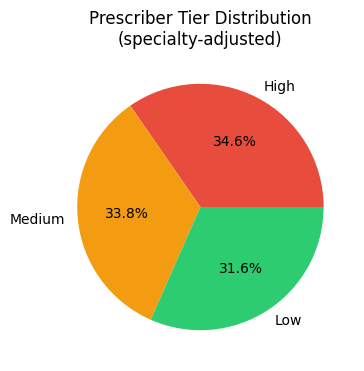

In [69]:
# ── Fix FutureWarning + handle single-doctor specialties ──

def assign_specialty_tier(group):
    n = len(group)
    
    if n == 1:
        # Only 1 doctor in specialty → can't tier → assign Medium
        group = group.copy()
        group['Prescriber_Tier'] = 'Medium'
        return group
    
    elif n == 2:
        # Only 2 doctors → High and Low only
        group = group.copy()
        sorted_idx = group['Total_Claims'].rank(method='first')
        group['Prescriber_Tier'] = sorted_idx.map(
            {1.0: 'Low', 2.0: 'High'}
        )
        return group
    
    else:
        low_cut  = group['Total_Claims'].quantile(0.33)
        high_cut = group['Total_Claims'].quantile(0.66)
        
        group = group.copy()
        group['Prescriber_Tier'] = group['Total_Claims'].apply(
            lambda x: 'High' if x >= high_cut 
                      else ('Medium' if x >= low_cut else 'Low')
        )
        return group

# ── Apply with include_groups=False to fix warning ────
doctor_df['Prescriber_Tier'] = doctor_df.groupby(
    'Prscrbr_Type', group_keys=False
)[['Prscrbr_Type', 'Total_Claims']].apply(
    assign_specialty_tier, include_groups=False
)['Prescriber_Tier']

# ── Check distribution ─────────────────────────────────
print("Overall Tier Distribution:")
print(doctor_df['Prescriber_Tier'].value_counts())
print(f"\nTotal doctors: {len(doctor_df)}")

# ── Visual ─────────────────────────────────────────────
import matplotlib.pyplot as plt

colors  = {'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#2ecc71'}
tier_counts = doctor_df['Prescriber_Tier'].value_counts()

plt.figure(figsize=(6, 4))
plt.pie(tier_counts,
        labels=tier_counts.index,
        autopct='%1.1f%%',
        colors=[colors[t] for t in tier_counts.index])
plt.title('Prescriber Tier Distribution\n(specialty-adjusted)')
plt.show()

In [71]:
from sklearn.preprocessing import LabelEncoder

# ── Check what we have in doctor_df ───────────────────
print("Columns:", doctor_df.columns.tolist())
print("Shape:", doctor_df.shape)
print("\nTarget distribution:")
print(doctor_df['Prescriber_Tier'].value_counts())

Columns: ['Prscrbr_NPI', 'Prscrbr_Last_Org_Name', 'Prscrbr_First_Name', 'Prscrbr_Type', 'Prscrbr_City', 'Total_Claims', 'Total_Cost', 'Total_Patients', 'Unique_Drugs', 'Avg_Refill_Rate', 'Avg_Cost_Per_Claim', 'Avg_Senior_Ratio', 'Prescriber_Tier']
Shape: (231, 13)

Target distribution:
Prescriber_Tier
High      80
Medium    78
Low       73
Name: count, dtype: int64


In [73]:
# ── Features we USE ───────────────────────────────────
# Numeric — directly usable
numeric_features = [
    'Total_Claims',       # total prescriptions written
    'Total_Cost',         # total drug cost
    'Total_Patients',     # total unique patients
    'Unique_Drugs',       # how many different drugs prescribed
    'Avg_Refill_Rate',    # chronic vs acute prescriber
    'Avg_Cost_Per_Claim', # cheap vs expensive drugs
    'Avg_Senior_Ratio',   # elderly patient focus
]

# Categorical — needs encoding
categorical_features = [
    'Prscrbr_Type',   # specialty
    'Prscrbr_City',   # location
]

# ── Features we DROP ──────────────────────────────────
# Prscrbr_NPI          → just an ID, no predictive value
# Prscrbr_Last_Org_Name → just a name
# Prscrbr_First_Name   → just a name

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("\nSample data:")
print(doctor_df[numeric_features + categorical_features].head(10))

Numeric features: 7
Categorical features: 2

Sample data:
   Total_Claims  Total_Cost  Total_Patients  Unique_Drugs  Avg_Refill_Rate  \
0          5619   302941.60          3007.0            38         1.861220   
1           797   887930.84           444.0            29         1.928307   
2          1211   745801.61           785.0            24         1.623868   
3            91     1521.93            57.0             5         1.570629   
4            24       92.11            20.0             1         1.200000   
5            52      190.59            45.0             1         1.155556   
6            31      127.94            27.0             1         1.148148   
7            71     9779.52            68.0             5         1.044848   
8          1597   137516.97           825.0            47         1.872020   
9            24      114.25            19.0             1         1.263158   

   Avg_Cost_Per_Claim  Avg_Senior_Ratio         Prscrbr_Type  Prscrbr_City  
0     

In [74]:
from sklearn.preprocessing import LabelEncoder

# ── Encode Specialty ───────────────────────────────────
le_type = LabelEncoder()
doctor_df['Specialty_Enc'] = le_type.fit_transform(doctor_df['Prscrbr_Type'])

# ── Encode City ────────────────────────────────────────
le_city = LabelEncoder()
doctor_df['City_Enc'] = le_city.fit_transform(doctor_df['Prscrbr_City'])

# ── Encode Target ──────────────────────────────────────
le_tier = LabelEncoder()
doctor_df['Target'] = le_tier.fit_transform(doctor_df['Prescriber_Tier'])

# ── Check encoding ─────────────────────────────────────
print("Specialty encoding sample:")
print(dict(zip(le_type.classes_, le_type.transform(le_type.classes_))))

print("\nTarget encoding:")
print(dict(zip(le_tier.classes_, le_tier.transform(le_tier.classes_))))

print("\nTarget distribution after encoding:")
print(doctor_df['Target'].value_counts())

Specialty encoding sample:
{'Allergy/ Immunology': np.int64(0), 'Anesthesiology': np.int64(1), 'Cardiology': np.int64(2), 'Dentist': np.int64(3), 'Dermatology': np.int64(4), 'Emergency Medicine': np.int64(5), 'Endocrinology': np.int64(6), 'Family Practice': np.int64(7), 'Gastroenterology': np.int64(8), 'General Practice': np.int64(9), 'General Surgery': np.int64(10), 'Geriatric Medicine': np.int64(11), 'Hand Surgery': np.int64(12), 'Hospitalist': np.int64(13), 'Infectious Disease': np.int64(14), 'Internal Medicine': np.int64(15), 'Interventional Pain Management': np.int64(16), 'Nephrology': np.int64(17), 'Neurology': np.int64(18), 'Neurosurgery': np.int64(19), 'Nurse Practitioner': np.int64(20), 'Obstetrics & Gynecology': np.int64(21), 'Ophthalmology': np.int64(22), 'Optometry': np.int64(23), 'Oral Surgery (Dentist only)': np.int64(24), 'Orthopedic Surgery': np.int64(25), 'Otolaryngology': np.int64(26), 'Pain Management': np.int64(27), 'Pharmacist': np.int64(28), 'Physician Assistant':

In [76]:
from sklearn.model_selection import train_test_split

# ── Final feature list ─────────────────────────────────
feature_cols = [
    'Total_Claims',
    'Total_Cost',
    'Total_Patients',
    'Unique_Drugs',
    'Avg_Refill_Rate',
    'Avg_Cost_Per_Claim',
    'Avg_Senior_Ratio',
    'Specialty_Enc',
    'City_Enc'
]

X = doctor_df[feature_cols]
y = doctor_df['Target']

# ── Split ──────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # reproducible results
    stratify=y           # keep tier balance in both sets
)

print(f"Total doctors:    {len(X)}")
print(f"Training set:     {len(X_train)} doctors")
print(f"Test set:         {len(X_test)} doctors")

print("\nClass balance in training set:")
print(y_train.value_counts())

print("\nClass balance in test set:")
print(y_test.value_counts())



Total doctors:    231
Training set:     184 doctors
Test set:         47 doctors

Class balance in training set:
Target
0    64
2    62
1    58
Name: count, dtype: int64

Class balance in test set:
Target
0    16
2    16
1    15
Name: count, dtype: int64


In [78]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# ── Scale features for Logistic Regression ────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── Train all 3 models ─────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}

for name, model in models.items():
    # Logistic Regression needs scaled data
    if name == 'Logistic Regression':
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        'model':  model,
        'y_pred': y_pred,
        'accuracy': acc
    }

    print(f"\n{'─'*45}")
    print(f"📌 {name}")
    print(f"   Accuracy: {acc:.4f}")
    print(classification_report(
        y_test, y_pred,
        target_names=le_tier.classes_
    ))

# ── Best model ─────────────────────────────────────────
best_name = max(results, key=lambda k: results[k]['accuracy'])
print(f"\n🏆 Best Model: {best_name}")
print(f"   Accuracy: {results[best_name]['accuracy']:.4f}")




─────────────────────────────────────────────
📌 Logistic Regression
   Accuracy: 0.6170
              precision    recall  f1-score   support

        High       0.75      0.56      0.64        16
         Low       0.54      0.87      0.67        15
      Medium       0.64      0.44      0.52        16

    accuracy                           0.62        47
   macro avg       0.64      0.62      0.61        47
weighted avg       0.64      0.62      0.61        47


─────────────────────────────────────────────
📌 Random Forest
   Accuracy: 0.7234
              precision    recall  f1-score   support

        High       0.86      0.75      0.80        16
         Low       0.70      0.93      0.80        15
      Medium       0.62      0.50      0.55        16

    accuracy                           0.72        47
   macro avg       0.72      0.73      0.72        47
weighted avg       0.72      0.72      0.72        47


─────────────────────────────────────────────
📌 Gradient Boosting

In [79]:
# ── Attribution Score for each doctor ─────────────────
def normalize(series):
    mn, mx = series.min(), series.max()
    return ((series - mn) / (mx - mn + 1e-9)) * 100

# ── Normalize each metric ──────────────────────────────
doctor_df['Claims_Score']   = normalize(doctor_df['Total_Claims'])
doctor_df['Cost_Score']     = normalize(doctor_df['Total_Cost'])
doctor_df['Patients_Score'] = normalize(doctor_df['Total_Patients'])
doctor_df['Drugs_Score']    = normalize(doctor_df['Unique_Drugs'])

# ── Weighted composite score ───────────────────────────
# Total Claims     → 40% (most important — volume)
# Total Cost       → 25% (drug value)
# Total Patients   → 25% (reach)
# Unique Drugs     → 10% (breadth)
doctor_df['HCP_Attribution_Score'] = (
    doctor_df['Claims_Score']   * 0.40 +
    doctor_df['Cost_Score']     * 0.25 +
    doctor_df['Patients_Score'] * 0.25 +
    doctor_df['Drugs_Score']    * 0.10
).round(2)

# ── Sort by score ──────────────────────────────────────
doctor_df = doctor_df.sort_values(
    'HCP_Attribution_Score', ascending=False
).reset_index(drop=True)

# ── Preview top 10 ────────────────────────────────────
print("🏆 TOP 10 PRESCRIPTION SOURCES:")
print(doctor_df[[
    'Prscrbr_First_Name', 'Prscrbr_Last_Org_Name',
    'Prscrbr_Type', 'Prscrbr_City',
    'Total_Claims', 'Unique_Drugs',
    'HCP_Attribution_Score', 'Prescriber_Tier'
]].head(10).to_string(index=False))

🏆 TOP 10 PRESCRIPTION SOURCES:
Prscrbr_First_Name Prscrbr_Last_Org_Name      Prscrbr_Type Prscrbr_City  Total_Claims  Unique_Drugs  HCP_Attribution_Score Prescriber_Tier
             Aaron                  Jeng Internal Medicine  San Gabriel          9588           162                  79.98            High
            Niceto                 Lopez Internal Medicine Walnut Creek          8971           156                  72.40            High
           Patrick              Richards     Endocrinology   Sacramento          5163            44                  61.86            High
       Christopher                Swales   Family Practice        Davis          6559           127                  56.11            High
              Neda               Heidari         Neurology       Oxnard          5343            69                  53.49            High
           Tiffney                Taylor Internal Medicine    Templeton          6191           107                  52.61            H